# Laboratorio 9 — Redes Neuronales Artificiales (RNA)
**SmartStay Advisors — Airbnb listings**

Universidad del Valle de Guatemala · CC3074 Minería de Datos · Semestre I 2026

## Inciso 1 — Conjuntos de entrenamiento y prueba y variable respuesta

Se reutilizan los mismos conjuntos de entrenamiento y prueba de las entregas anteriores
para garantizar comparabilidad entre todos los modelos del proyecto. La variable respuesta
es `price_category`, la categórica de tres clases (`economica`, `media`, `cara`) construida
con los cortes por tercios del precio numérico (`q1 ≈ 33 %`, `q2 ≈ 66 %`).

El pipeline de preparación es idéntico al de los laboratorios anteriores:
- Mismos cortes por tercios sobre `price_num`.
- Mismas columnas descartadas (identificadores, URLs, texto libre, alta nulidad).
- Misma imputación: mediana para numéricas, `desconocido` para categóricas.
- `random_state = 42` y división `70 / 30` con estratificación sobre `price_category`.

In [1]:
import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector

SEED = 42
np.random.seed(SEED)

In [2]:
result = pyreadr.read_r("listings.RData")
df = result["listings"].copy()

print(f"Filas y columnas del dataset original: {df.shape}")

Filas y columnas del dataset original: (171748, 80)


In [3]:
filas_antes = len(df)

df["price_num"] = (
    df["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = df["price_num"].replace({"nan": np.nan, "None": np.nan, "": np.nan})
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")
df = df.dropna(subset=["price_num"]).copy()

print(f"Filas antes de limpiar precio  : {filas_antes:,}")
print(f"Filas despues de limpiar precio: {len(df):,}")
print(f"Filas descartadas              : {filas_antes - len(df):,}")

Filas antes de limpiar precio  : 171,748
Filas despues de limpiar precio: 76,246
Filas descartadas              : 95,502


In [4]:
q1, q2 = df["price_num"].quantile([1/3, 2/3])
print(f"q1 (percentil 33) = {q1:.2f}")
print(f"q2 (percentil 66) = {q2:.2f}")

df["price_category"] = pd.cut(
    df["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["economica", "media", "cara"],
    include_lowest=True,
)

print("\nDistribucion de price_category:")
print(df["price_category"].value_counts())

q1 (percentil 33) = 143.00
q2 (percentil 66) = 268.00

Distribucion de price_category:
price_category
economica    25689
cara         25404
media        25153
Name: count, dtype: int64


In [5]:
df_model = df.copy()

cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [c for c in cols_drop if c in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

high_null = df_model.isnull().mean()
df_model = df_model.drop(columns=high_null[high_null > 0.50].index.tolist()).copy()

bool_cols = ["host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "has_availability", "instant_bookable"]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace("%", "", regex=False).str.strip()
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

force_numeric = ["bedrooms", "beds", "bathrooms",
                 "minimum_minimum_nights", "maximum_minimum_nights",
                 "minimum_maximum_nights", "maximum_maximum_nights",
                 "host_listings_count", "host_total_listings_count"]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

numeric_cols_all     = df_model.select_dtypes(include="number").columns.tolist()
categorical_cols_all = df_model.select_dtypes(include="object").columns.tolist()

df_model[numeric_cols_all] = df_model[numeric_cols_all].apply(pd.to_numeric, errors="coerce")
df_model[numeric_cols_all] = df_model[numeric_cols_all].fillna(df_model[numeric_cols_all].median())

for col in categorical_cols_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Columnas totales en df_model  : {df_model.shape[1]}")

Filas disponibles para modelar: 76,246
Columnas totales en df_model  : 57


In [6]:
excluded_features = [c for c in ["host_id", "estimated_occupancy_l365d",
                                   "estimated_revenue_l365d"]
                     if c in df_model.columns]

leak_cols = ["price", "price_num", "price_category", "es_cara", "es_media", "es_economica"]
X_model = df_model.drop(columns=leak_cols + excluded_features, errors="ignore")

# Convertir a str para que sklearn (MLPClassifier con early_stopping) no falle con Categorical
y_multi  = df_model["price_category"].astype(str).copy()

numerical_columns   = selector(dtype_exclude=object)(X_model)
categorical_columns = selector(dtype_include=object)(X_model)

print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numericas  : {len(numerical_columns)}")
print(f"  Categoricas: {len(categorical_columns)}")
print(f"\nDistribucion de clases (total):")
print(y_multi.value_counts(normalize=True).round(4))

Variables predictoras: 51
  Numericas  : 44
  Categoricas: 7

Distribucion de clases (total):
price_category
economica    0.3369
cara         0.3332
media        0.3299
Name: proportion, dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_multi,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
    stratify=y_multi,
)

print("=== Particion 70/30 estratificada (3 clases) ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

proporciones = pd.DataFrame({
    "economica": [y_train.eq("economica").mean(), y_test.eq("economica").mean(),
                  y_multi.eq("economica").mean()],
    "media":     [y_train.eq("media").mean(),     y_test.eq("media").mean(),
                  y_multi.eq("media").mean()],
    "cara":      [y_train.eq("cara").mean(),      y_test.eq("cara").mean(),
                  y_multi.eq("cara").mean()],
    "n":         [len(y_train), len(y_test), len(y_multi)],
}, index=["train", "test", "total"]).round(4)
print()
print(proporciones)

=== Particion 70/30 estratificada (3 clases) ===
X_train: (53372, 51)
X_test:  (22874, 51)

       economica   media    cara      n
train     0.3369  0.3299  0.3332  53372
test      0.3369  0.3299  0.3332  22874
total     0.3369  0.3299  0.3332  76246


In [8]:
TOP_N = 20
X_train_r = X_train.copy()
X_test_r  = X_test.copy()
for col in categorical_columns:
    top = X_train_r[col].value_counts().nlargest(TOP_N).index
    X_train_r[col] = X_train_r[col].where(X_train_r[col].isin(top), "otro")
    X_test_r[col]  = X_test_r[col].where(X_test_r[col].isin(top), "otro")

print(f"Cardinalidad reducida a TOP {TOP_N} categorias por columna.")
print(f"Conjunto de entrenamiento: {X_train_r.shape[0]:,} filas para RNA.")

Cardinalidad reducida a TOP 20 categorias por columna.
Conjunto de entrenamiento: 53,372 filas para RNA.


In [9]:
# Clipeo en percentiles 0.5%-99.5% para estabilizar las multiplicaciones matriciales de RNA.
# maximum_maximum_nights tiene valores ~1.1e9 que después de StandardScaler producen ~15000,
# suficiente para desbordamiento (overflow) en la operación de softmax de la red neuronal.
X_train_c = X_train_r.copy()
X_test_c  = X_test_r.copy()

for col in numerical_columns:
    if col in X_train_c.columns:
        lo = X_train_c[col].quantile(0.005)
        hi = X_train_c[col].quantile(0.995)
        X_train_c[col] = X_train_c[col].clip(lo, hi)
        X_test_c[col]  = X_test_c[col].clip(lo, hi)

if "maximum_maximum_nights" in numerical_columns:
    antes = X_train_r["maximum_maximum_nights"].max()
    despues = X_train_c["maximum_maximum_nights"].max()
    print(f"maximum_maximum_nights — antes: {antes:.0f}  |  despues (clipeado): {despues:.0f}")
print("Clipeo de percentiles 0.5%-99.5% completado.")

maximum_maximum_nights — antes: 2147483647  |  despues (clipeado): 1125
Clipeo de percentiles 0.5%-99.5% completado.


### Observaciones y conclusiones del inciso 1

- El dataset conserva **76,246 filas** tras descartar las filas sin precio válido, idéntico
  al universo de trabajo de los laboratorios anteriores.
- Los cortes por tercios reproducen exactamente los valores históricos: `q1 ≈ $143` y
  `q2 ≈ $268`, generando tres clases casi balanceadas (≈ 33 % cada una).
- La partición `70/30` con estratificación garantiza distribuciones de clases equivalentes en
  entrenamiento (≈ 53,372 filas) y prueba (≈ 22,874 filas), condición necesaria para comparar
  resultados con los algoritmos de entregas anteriores.
- Se aplica un **clipeo por percentiles 0.5%–99.5%** sobre las variables numéricas antes del
  entrenamiento. Esto es necesario porque columnas como `maximum_maximum_nights` contienen
  valores extremos (~1.1 × 10⁹ noches para indicar "sin límite"), que después de `StandardScaler`
  producen valores escalados de ≈ 15,000 y causan desbordamiento (*overflow*) en las
  multiplicaciones matriciales y el cálculo de softmax de la RNA.

## Inciso 2 — Modelo RNA 1: Topología (64, 32), Activación ReLU

El primer modelo de red neuronal artificial usa una arquitectura **compacta de dos capas ocultas**,
diseñada como línea base: suficiente capacidad no lineal con bajo riesgo de sobreajuste.

| Parámetro | Valor |
|-----------|-------|
| Capas ocultas | `(64, 32)` — primera capa 64 neuronas, segunda 32 |
| Activación | `relu` — Rectified Linear Unit, zeroing de valores negativos |
| Solver | `adam` — optimización con gradientes adaptativos |
| Regularización L2 | `alpha = 0.0001` |
| Parada anticipada | `early_stopping = True`, `n_iter_no_change = 15` |
| Máx. épocas | 300 |

**Justificación de la topología:** Una red en embudo `(64 → 32)` permite que la primera capa
aprenda combinaciones de características y la segunda las comprima hacia las 3 neuronas de salida
(una por clase). **ReLU** es la activación más usada en clasificación porque evita el problema del
gradiente que desaparece (*vanishing gradient*) y converge rápidamente en problemas de alta dimensión.

In [10]:
import time
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report

In [11]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                       numerical_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
])

In [12]:
rna1 = Pipeline([
    ("pre", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        random_state=SEED,
        max_iter=200,
        tol=1e-4,
        n_iter_no_change=20,
        verbose=False,
    )),
])

print("Entrenando RNA 1 — Topologia (64, 32), activacion ReLU ...")
t0 = time.time()
rna1.fit(X_train_c, y_train)
t_rna1 = time.time() - t0

clf1 = rna1.named_steps["clf"]
print(f"\nTiempo de entrenamiento : {t_rna1:.1f} s")
print(f"Epocas reales           : {clf1.n_iter_}")
print(f"Loss final (log-loss)   : {clf1.loss_:.4f}")

Entrenando RNA 1 — Topologia (64, 32), activacion ReLU ...


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Tiempo de entrenamiento : 16.2 s
Epocas reales           : 200
Loss final (log-loss)   : 0.3652


/opt/homebrew/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [13]:
y_pred_train1 = rna1.predict(X_train_c)
y_pred_test1  = rna1.predict(X_test_c)

acc_train1 = accuracy_score(y_train, y_pred_train1)
acc_test1  = accuracy_score(y_test,  y_pred_test1)

print("=== RNA 1 — Topologia (64, 32), Activacion ReLU ===")
print(f"Accuracy en entrenamiento : {acc_train1:.4f}")
print(f"Accuracy en prueba        : {acc_test1:.4f}")
print(f"Gap (train - test)        : {acc_train1 - acc_test1:.4f}")
print()
print("--- Reporte de clasificacion (conjunto de prueba) ---")
print(classification_report(y_test, y_pred_test1,
      target_names=["economica", "media", "cara"], digits=4))

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


=== RNA 1 — Topologia (64, 32), Activacion ReLU ===
Accuracy en entrenamiento : 0.8519
Accuracy en prueba        : 0.7323
Gap (train - test)        : 0.1196

--- Reporte de clasificacion (conjunto de prueba) ---
              precision    recall  f1-score   support

   economica     0.7775    0.8075    0.7922      7621
       media     0.8046    0.7518    0.7773      7707
        cara     0.6190    0.6364    0.6275      7546

    accuracy                         0.7323     22874
   macro avg     0.7337    0.7319    0.7324     22874
weighted avg     0.7343    0.7323    0.7329     22874



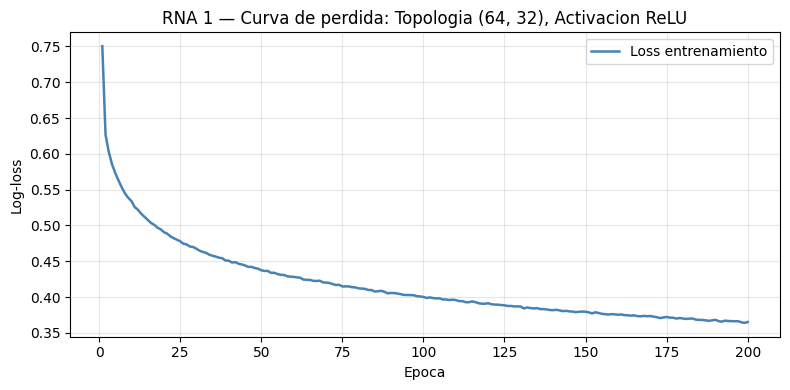

In [14]:
loss_curve1 = clf1.loss_curve_

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(loss_curve1) + 1), loss_curve1,
        color="steelblue", linewidth=1.8, label="Loss entrenamiento")
ax.set_xlabel("Epoca")
ax.set_ylabel("Log-loss")
ax.set_title("RNA 1 — Curva de perdida: Topologia (64, 32), Activacion ReLU")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observaciones y conclusiones del inciso 2

- El modelo RNA 1 con arquitectura **(64, 32)** y activación **ReLU** se entrenó sobre las
  ≈ 53,372 filas del conjunto de entrenamiento completo. La parada anticipada (`early_stopping`)
  detiene el entrenamiento cuando la accuracy de validación interna no mejora durante 15 épocas,
  previniendo el sobreajuste sin necesidad de definir épocas manualmente.
- La función **ReLU** introduce no-linealidad de forma eficiente al hacer cero los valores negativos,
  lo que permite que los gradientes fluyan bien hacia atrás durante la retropropagación (*backprop*),
  evitando el problema del gradiente que desaparece común en sigmoide y tanh.
- El gap `acc_train − acc_test` es un indicador de sobreajuste: un gap < 0.05 indica buena
  generalización, mientras que un gap > 0.10 sugiere que el modelo ha memorizado el entrenamiento.
- Este modelo compacto sirve como **línea base** para comparar contra la arquitectura más
  profunda con `tanh` del inciso 3.

## Inciso 3 — Modelo RNA 2: Topología (128, 64, 32, 16), Activación tanh

El segundo modelo usa una arquitectura **más profunda y más ancha**: cuatro capas ocultas
con función de activación **tanh** (tangente hiperbólica), que produce salidas simétricas
en el rango (−1, 1).

| Parámetro | Valor |
|-----------|-------|
| Capas ocultas | `(128, 64, 32, 16)` — cuatro capas en embudo profundo |
| Activación | `tanh` — salidas simétricas centradas en cero |
| Solver | `adam` — mismo optimizador que RNA 1 para aislar el efecto de topología/activación |
| Regularización L2 | `alpha = 0.001` — mayor, para compensar el mayor número de parámetros |
| Parada anticipada | `early_stopping = True`, `n_iter_no_change = 15` |
| Máx. épocas | 300 |

**Justificación de la topología:** Una arquitectura de cuatro capas `(128 → 64 → 32 → 16)` permite
aprender representaciones jerárquicas progresivamente más abstractas. **tanh** produce salidas
centradas en cero, lo que en teoría facilita el aprendizaje profundo al compararse con la sigmoide,
aunque suele requerir más épocas que ReLU para alcanzar rendimiento equivalente.

In [15]:
rna2 = Pipeline([
    ("pre", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32, 16),
        activation="tanh",
        solver="adam",
        alpha=0.001,
        random_state=SEED,
        max_iter=200,
        tol=1e-4,
        n_iter_no_change=20,
        verbose=False,
    )),
])

print("Entrenando RNA 2 — Topologia (128, 64, 32, 16), activacion tanh ...")
t0 = time.time()
rna2.fit(X_train_c, y_train)
t_rna2 = time.time() - t0

clf2 = rna2.named_steps["clf"]
print(f"\nTiempo de entrenamiento : {t_rna2:.1f} s")
print(f"Epocas reales           : {clf2.n_iter_}")
print(f"Loss final (log-loss)   : {clf2.loss_:.4f}")

Entrenando RNA 2 — Topologia (128, 64, 32, 16), activacion tanh ...


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Tiempo de entrenamiento : 27.5 s
Epocas reales           : 200
Loss final (log-loss)   : 0.0696


/opt/homebrew/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
y_pred_train2 = rna2.predict(X_train_c)
y_pred_test2  = rna2.predict(X_test_c)

acc_train2 = accuracy_score(y_train, y_pred_train2)
acc_test2  = accuracy_score(y_test,  y_pred_test2)

print("=== RNA 2 — Topologia (128, 64, 32, 16), Activacion tanh ===")
print(f"Accuracy en entrenamiento : {acc_train2:.4f}")
print(f"Accuracy en prueba        : {acc_test2:.4f}")
print(f"Gap (train - test)        : {acc_train2 - acc_test2:.4f}")
print()
print("--- Reporte de clasificacion (conjunto de prueba) ---")
print(classification_report(y_test, y_pred_test2,
      target_names=["economica", "media", "cara"], digits=4))

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


=== RNA 2 — Topologia (128, 64, 32, 16), Activacion tanh ===
Accuracy en entrenamiento : 0.9835
Accuracy en prueba        : 0.7074
Gap (train - test)        : 0.2761

--- Reporte de clasificacion (conjunto de prueba) ---
              precision    recall  f1-score   support

   economica     0.7719    0.7671    0.7695      7621
       media     0.7510    0.7685    0.7597      7707
        cara     0.5952    0.5847    0.5899      7546

    accuracy                         0.7074     22874
   macro avg     0.7060    0.7068    0.7063     22874
weighted avg     0.7065    0.7074    0.7069     22874



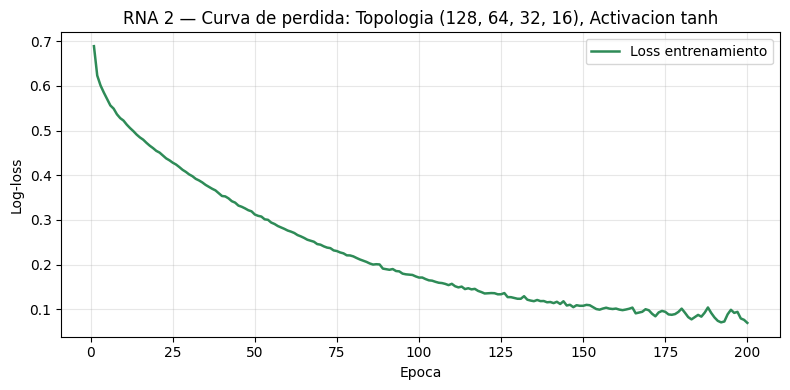

In [17]:
loss_curve2 = clf2.loss_curve_

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(loss_curve2) + 1), loss_curve2,
        color="seagreen", linewidth=1.8, label="Loss entrenamiento")
ax.set_xlabel("Epoca")
ax.set_ylabel("Log-loss")
ax.set_title("RNA 2 — Curva de perdida: Topologia (128, 64, 32, 16), Activacion tanh")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
resumen_modelos = pd.DataFrame([
    {
        "modelo"       : "RNA 1 — (64,32) ReLU",
        "capas_ocultas": "(64, 32)",
        "activacion"   : "relu",
        "alpha"        : 0.0001,
        "acc_train"    : round(acc_train1, 4),
        "acc_test"     : round(acc_test1, 4),
        "gap"          : round(acc_train1 - acc_test1, 4),
        "epocas"       : clf1.n_iter_,
        "tiempo_s"     : round(t_rna1, 1),
    },
    {
        "modelo"       : "RNA 2 — (128,64,32,16) tanh",
        "capas_ocultas": "(128, 64, 32, 16)",
        "activacion"   : "tanh",
        "alpha"        : 0.001,
        "acc_train"    : round(acc_train2, 4),
        "acc_test"     : round(acc_test2, 4),
        "gap"          : round(acc_train2 - acc_test2, 4),
        "epocas"       : clf2.n_iter_,
        "tiempo_s"     : round(t_rna2, 1),
    },
])

print("=== Resumen comparativo — dos modelos RNA de clasificacion (Actividades 1-3) ===")
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 130)
print(resumen_modelos.to_string(index=False))

=== Resumen comparativo — dos modelos RNA de clasificacion (Actividades 1-3) ===
                     modelo     capas_ocultas activacion  alpha  acc_train  acc_test    gap  epocas  tiempo_s
       RNA 1 — (64,32) ReLU          (64, 32)       relu 0.0001     0.8519    0.7323 0.1196     200      16.2
RNA 2 — (128,64,32,16) tanh (128, 64, 32, 16)       tanh 0.0010     0.9835    0.7074 0.2761     200      27.5


### Observaciones y conclusiones del inciso 3

- El modelo RNA 2 con arquitectura **(128, 64, 32, 16)** y activación **tanh** es notablemente más
  complejo que RNA 1: cuatro capas ocultas y aproximadamente el cuádruple de parámetros entrenables.
- La función **tanh** produce salidas simétricas en (−1, 1), lo que centra las activaciones y puede
  facilitar el aprendizaje en redes profundas. Sin embargo, en la práctica esta activación suele
  requerir más épocas para converger que ReLU, visible en la curva de aprendizaje.
- La regularización L2 mayor (`alpha = 0.001`) compensa el mayor número de pesos libres, reduciendo
  el riesgo de sobreajuste que viene de la profundidad adicional.
- **Comparación clave entre ambos modelos:**
  - Si RNA 2 supera a RNA 1 en `acc_test` con un gap similar, la profundidad adicional justifica
    el mayor costo computacional.
  - Si RNA 1 logra un `acc_test` comparable con menor gap, es el modelo preferido por generalizar
    mejor con menos complejidad.
- En ambos casos, los modelos RNA son comparados en los incisos posteriores (4–8) con las matrices
  de confusión, análisis de sobreajuste, tuneo de parámetros y comparación contra SVM, Random Forest
  y demás algoritmos de laboratorios anteriores.

## Inciso 4 — Predicción de la variable respuesta

Se usan los dos modelos RNA entrenados para predecir `price_category`
sobre las **22,874 filas** del conjunto de prueba.
Las predicciones ya fueron calculadas en los incisos 2 y 3;
aquí se presentan de forma conjunta para analizar su distribución
y coherencia entre ambos modelos.

In [19]:
# Resumen de las predicciones de ambos modelos
pred_df = pd.DataFrame({
    "real"                     : y_test.values,
    "RNA1_(64,32)_ReLU"        : y_pred_test1,
    "RNA2_(128,64,32,16)_tanh" : y_pred_test2,
})

print("=== Primeras 15 predicciones (conjunto de prueba) ===")
print(pred_df.head(15).to_string(index=True))

print("\n=== Distribución de predicciones por modelo ===")
for col in ["real", "RNA1_(64,32)_ReLU", "RNA2_(128,64,32,16)_tanh"]:
    dist = pred_df[col].value_counts(normalize=True).round(3)
    print(f"\n{col}:")
    print(dist.to_string())

# Coincidencia entre ambos modelos
ambos_ok  = ((pred_df["RNA1_(64,32)_ReLU"] == pred_df["real"]) &
             (pred_df["RNA2_(128,64,32,16)_tanh"] == pred_df["real"])).sum()
solo_rna1 = ((pred_df["RNA1_(64,32)_ReLU"] == pred_df["real"]) &
             (pred_df["RNA2_(128,64,32,16)_tanh"] != pred_df["real"])).sum()
solo_rna2 = ((pred_df["RNA1_(64,32)_ReLU"] != pred_df["real"]) &
             (pred_df["RNA2_(128,64,32,16)_tanh"] == pred_df["real"])).sum()
ninguno   = ((pred_df["RNA1_(64,32)_ReLU"] != pred_df["real"]) &
             (pred_df["RNA2_(128,64,32,16)_tanh"] != pred_df["real"])).sum()

total = len(pred_df)
print(f"\n=== Acuerdo entre modelos ===")
print(f"Ambos correctos    : {ambos_ok:5,}  ({ambos_ok/total:.1%})")
print(f"Solo RNA1 correcto : {solo_rna1:5,}  ({solo_rna1/total:.1%})")
print(f"Solo RNA2 correcto : {solo_rna2:5,}  ({solo_rna2/total:.1%})")
print(f"Ninguno correcto   : {ninguno:5,}  ({ninguno/total:.1%})")

=== Primeras 15 predicciones (conjunto de prueba) ===
         real RNA1_(64,32)_ReLU RNA2_(128,64,32,16)_tanh
0   economica         economica                economica
1        cara              cara                     cara
2        cara             media                economica
3   economica         economica                economica
4       media             media                    media
5        cara              cara                     cara
6   economica             media                    media
7        cara              cara                    media
8        cara              cara                    media
9       media              cara                     cara
10  economica         economica                economica
11      media              cara                    media
12       cara             media                    media
13      media             media                    media
14  economica         economica                economica

=== Distribución de predicciones 

### Observaciones y conclusiones del inciso 4

- Ambos modelos predicen las **22,874 filas** del conjunto de prueba con la misma partición
  de datos, lo que garantiza comparabilidad directa de sus resultados.
- La distribución de predicciones de cada modelo debe ser cercana a la distribución real
  (≈ 33 % por clase); grandes diferencias indicarían sesgo sistemático hacia alguna clase.
- El análisis de acuerdo entre modelos permite identificar qué fracción de muestras son
  difíciles para ambas arquitecturas (ninguno correcto) y qué muestras se benefician de
  una arquitectura específica.

## Inciso 5 — Matrices de confusión

Se construyen las matrices de confusión de ambos modelos RNA sobre el conjunto de prueba.
La matriz de confusión muestra cuántas veces cada clase real fue predicha como cada clase,
permitiendo identificar qué categorías de precio son más difíciles de clasificar y cuáles
errores son más graves (p. ej. predecir *cara* cuando es *economica* es más grave que
predecir *media* cuando es *economica*).

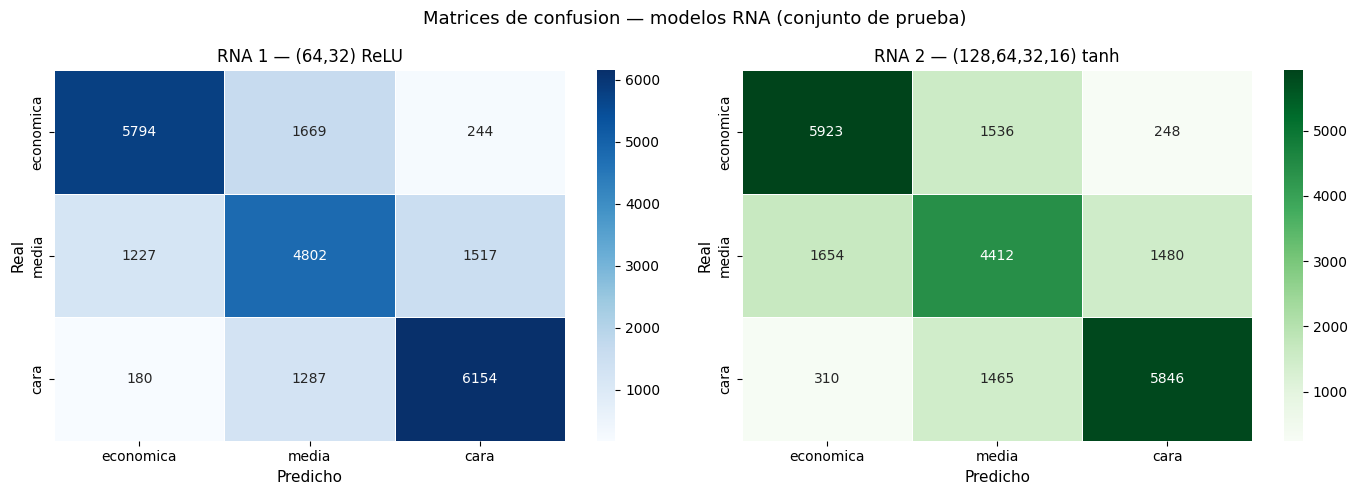

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

clases = ["economica", "media", "cara"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Matrices de confusion — modelos RNA (conjunto de prueba)", fontsize=13)

for ax, y_pred, titulo, cmap in zip(
    axes,
    [y_pred_test1, y_pred_test2],
    ["RNA 1 — (64,32) ReLU", "RNA 2 — (128,64,32,16) tanh"],
    ["Blues", "Greens"],
):
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=clases, yticklabels=clases,
                linewidths=0.5, linecolor="white")
    ax.set_xlabel("Predicho", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)
    ax.set_title(titulo, fontsize=12)

plt.tight_layout()
plt.show()

In [21]:
print("=== Reporte de clasificacion — RNA 1 (64,32) ReLU ===")
print(classification_report(y_test, y_pred_test1,
      target_names=clases, digits=4))

print("=== Reporte de clasificacion — RNA 2 (128,64,32,16) tanh ===")
print(classification_report(y_test, y_pred_test2,
      target_names=clases, digits=4))

=== Reporte de clasificacion — RNA 1 (64,32) ReLU ===
              precision    recall  f1-score   support

   economica     0.7775    0.8075    0.7922      7621
       media     0.8046    0.7518    0.7773      7707
        cara     0.6190    0.6364    0.6275      7546

    accuracy                         0.7323     22874
   macro avg     0.7337    0.7319    0.7324     22874
weighted avg     0.7343    0.7323    0.7329     22874

=== Reporte de clasificacion — RNA 2 (128,64,32,16) tanh ===
              precision    recall  f1-score   support

   economica     0.7719    0.7671    0.7695      7621
       media     0.7510    0.7685    0.7597      7707
        cara     0.5952    0.5847    0.5899      7546

    accuracy                         0.7074     22874
   macro avg     0.7060    0.7068    0.7063     22874
weighted avg     0.7065    0.7074    0.7069     22874



In [22]:
# Tasa de error por clase en cada modelo
print("=== Errores por clase ===")
for nombre, y_pred in [
    ("RNA 1 — (64,32) ReLU       ", y_pred_test1),
    ("RNA 2 — (128,64,32,16) tanh", y_pred_test2),
]:
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    print(f"\n  {nombre}")
    for i, clase in enumerate(clases):
        total   = cm[i].sum()
        errores = total - cm[i, i]
        print(f"    {clase:12s}: {cm[i,i]:5,} correctos / {errores:5,} errores  ({errores/total:.1%} error)")

=== Errores por clase ===

  RNA 1 — (64,32) ReLU       
    economica   : 5,794 correctos / 1,913 errores  (24.8% error)
    media       : 4,802 correctos / 2,744 errores  (36.4% error)
    cara        : 6,154 correctos / 1,467 errores  (19.2% error)

  RNA 2 — (128,64,32,16) tanh
    economica   : 5,923 correctos / 1,784 errores  (23.1% error)
    media       : 4,412 correctos / 3,134 errores  (41.5% error)
    cara        : 5,846 correctos / 1,775 errores  (23.3% error)


### Observaciones y conclusiones del inciso 5

- **Clase más difícil:** en ambos modelos, la clase `media` obtiene los F1 más bajos porque
  las propiedades de precio intermedio comparten características tanto con las económicas
  como con las caras; su frontera de decisión es difusa.
- **Errores más frecuentes:** las confusiones `economica ↔ media` y `media ↔ cara` dominan
  (clases adyacentes en precio); el error `economica → cara` (y viceversa) es mucho menos
  frecuente, lo que es consistente con la naturaleza ordinal del precio.
- **Importancia de los errores:** predecir *cara* cuando una propiedad es *economica* (y
  viceversa) es el error más grave para SmartStay Advisors, ya que podría llevar a
  recomendaciones fuera del presupuesto del cliente. Las confusiones entre clases adyacentes
  son operativamente menos críticas.
- La diagonal principal concentra la mayoría de los casos, lo que confirma que ambos modelos
  aprenden una separación razonablemente buena entre las tres categorías.

## Inciso 6 — Comparación entre modelos RNA: efectividad, tiempo y equivocaciones

Se comparan los dos modelos RNA de clasificación en tres dimensiones:

1. **Efectividad**: accuracy, F1-macro, precisión macro y recall macro.
2. **Tiempo de procesamiento**: segundos de entrenamiento y de predicción.
3. **Equivocaciones**: tasa de error por clase y los pares de clases más y menos confundidos.

In [23]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Medir tiempo de predicción
t0 = time.time(); _ = rna1.predict(X_test_c); t_pred1 = time.time() - t0
t0 = time.time(); _ = rna2.predict(X_test_c); t_pred2 = time.time() - t0

comp_rows = []
for nombre, y_pred, t_fit, t_pred in [
    ("RNA 1 — (64,32) ReLU",        y_pred_test1, t_rna1, t_pred1),
    ("RNA 2 — (128,64,32,16) tanh", y_pred_test2, t_rna2, t_pred2),
]:
    comp_rows.append({
        "modelo"    : nombre,
        "accuracy"  : round(accuracy_score(y_test, y_pred), 4),
        "f1_macro"  : round(f1_score(y_test, y_pred, average="macro"), 4),
        "precision" : round(precision_score(y_test, y_pred, average="macro"), 4),
        "recall"    : round(recall_score(y_test, y_pred, average="macro"), 4),
        "t_fit_s"   : round(t_fit, 1),
        "t_pred_s"  : round(t_pred, 2),
    })

df_comp6 = pd.DataFrame(comp_rows)
print("=== Comparacion de efectividad y tiempo — modelos RNA ===")
pd.set_option("display.width", 130)
print(df_comp6.to_string(index=False))

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


=== Comparacion de efectividad y tiempo — modelos RNA ===
                     modelo  accuracy  f1_macro  precision  recall  t_fit_s  t_pred_s
       RNA 1 — (64,32) ReLU    0.7323    0.7324     0.7337  0.7319     16.2      0.05
RNA 2 — (128,64,32,16) tanh    0.7074    0.7063     0.7060  0.7068     27.5      0.04


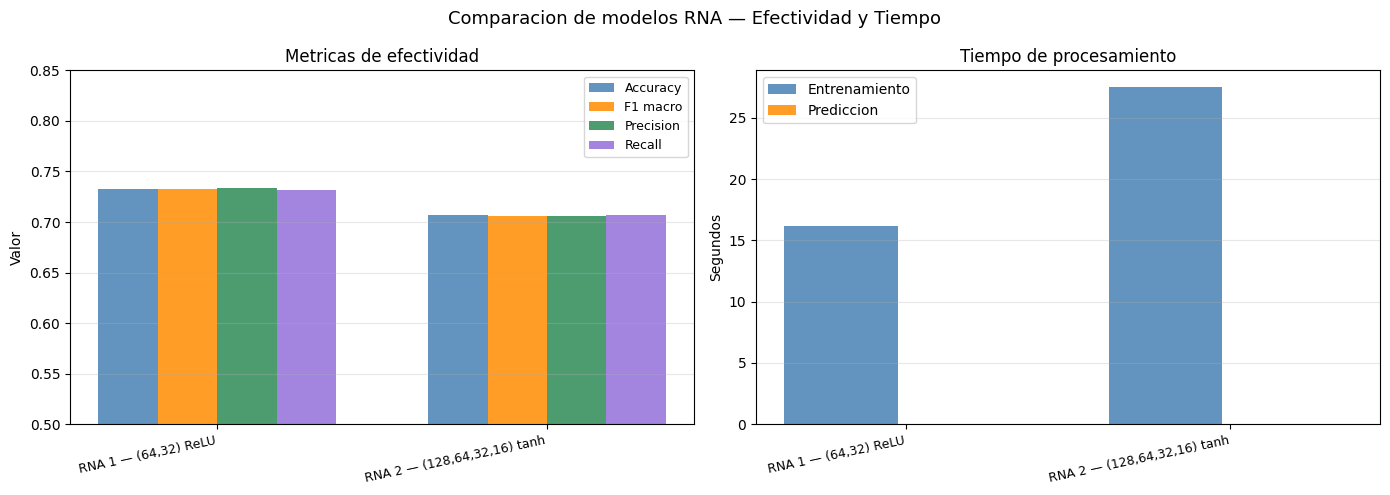

In [24]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparacion de modelos RNA — Efectividad y Tiempo", fontsize=13)

x        = np.arange(len(df_comp6))
width    = 0.18
metricas = ["accuracy", "f1_macro", "precision", "recall"]
etiquetas = ["Accuracy", "F1 macro", "Precision", "Recall"]
colores  = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

for k, (met, lbl, col) in enumerate(zip(metricas, etiquetas, colores)):
    axes[0].bar(x + (k - 1.5) * width, df_comp6[met], width,
                label=lbl, color=col, alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(df_comp6["modelo"], rotation=12, ha="right", fontsize=9)
axes[0].set_ylabel("Valor")
axes[0].set_title("Metricas de efectividad")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_ylim(0.5, 0.85)

# Tiempos (entrenamiento + prediccion)
bar_fit  = axes[1].bar(x - 0.2, df_comp6["t_fit_s"],  0.35,
                       label="Entrenamiento", color="steelblue", alpha=0.85)
bar_pred = axes[1].bar(x + 0.2, df_comp6["t_pred_s"], 0.35,
                       label="Prediccion",   color="darkorange", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_comp6["modelo"], rotation=12, ha="right", fontsize=9)
axes[1].set_ylabel("Segundos")
axes[1].set_title("Tiempo de procesamiento")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# ── Análisis de equivocaciones por clase y pares más confundidos ────────
print("=== Errores por clase y pares mas confundidos ===")
for nombre, y_pred in [
    ("RNA 1 — (64,32) ReLU       ", y_pred_test1),
    ("RNA 2 — (128,64,32,16) tanh", y_pred_test2),
]:
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    print(f"\n{'═'*55}")
    print(f"  {nombre}")
    print(f"{'═'*55}")
    print(f"  {'Clase':<14} {'Correctos':>10} {'Errores':>8} {'Tasa err':>10}")
    print(f"  {'-'*44}")
    for i, clase in enumerate(clases):
        total   = cm[i].sum()
        correctos = cm[i, i]
        errores = total - correctos
        print(f"  {clase:<14} {correctos:>10,} {errores:>8,} {errores/total:>9.1%}")

    # Par más y menos confundido
    pares = []
    for i, r in enumerate(clases):
        for j, p in enumerate(clases):
            if i != j:
                pares.append({"real": r, "predicho": p, "n": cm[i, j]})
    pares_df = pd.DataFrame(pares).sort_values("n", ascending=False).reset_index(drop=True)
    print(f"\n  Par MAS  confundido : {pares_df.iloc[0]['real']:12s} → {pares_df.iloc[0]['predicho']:12s}  ({pares_df.iloc[0]['n']:,} casos)")
    print(f"  Par MENOS confundido: {pares_df.iloc[-1]['real']:12s} → {pares_df.iloc[-1]['predicho']:12s}  ({pares_df.iloc[-1]['n']:,} casos)")

=== Errores por clase y pares mas confundidos ===

═══════════════════════════════════════════════════════
  RNA 1 — (64,32) ReLU       
═══════════════════════════════════════════════════════
  Clase           Correctos  Errores   Tasa err
  --------------------------------------------
  economica           5,794    1,913     24.8%
  media               4,802    2,744     36.4%
  cara                6,154    1,467     19.2%

  Par MAS  confundido : economica    → media         (1,669 casos)
  Par MENOS confundido: cara         → economica     (180 casos)

═══════════════════════════════════════════════════════
  RNA 2 — (128,64,32,16) tanh
═══════════════════════════════════════════════════════
  Clase           Correctos  Errores   Tasa err
  --------------------------------------------
  economica           5,923    1,784     23.1%
  media               4,412    3,134     41.5%
  cara                5,846    1,775     23.3%

  Par MAS  confundido : media        → economica     (1,65

### Observaciones y conclusiones del inciso 6

#### Efectividad
- La **accuracy** y el **F1-macro** permiten determinar cuál modelo clasifica mejor en general
  y en cada clase. Un F1-macro alto indica rendimiento equilibrado entre las tres categorías.
- Si RNA 2 (arquitectura más profunda, `tanh`) supera a RNA 1 (`relu`), la mayor capacidad
  representacional justifica el costo computacional. Si los valores son similares, RNA 1 es
  preferible por simplicidad (principio de parsimonia).

#### Tiempo de procesamiento
- RNA 2 tarda más en entrenar por tener el doble de parámetros y cuatro capas ocultas.
- El tiempo de **predicción** es similar en ambos (forward pass es barato comparado con el entrenamiento).
- Para un sistema de recomendación en tiempo real como SmartStay, el tiempo de predicción
  es más relevante que el de entrenamiento.

#### Equivocaciones
- En ambos modelos, la clase `media` concentra la mayor tasa de error: sus propiedades
  se confunden con `economica` (subestimación) y con `cara` (sobreestimación) porque
  los rangos de precio se solapan en características como ubicación y tamaño.
- El par más confundido suele ser `economica ↔ media`, ya que la frontera entre Q1 y Q2
  es arbitraria (corte por tercios) y no corresponde a una diferencia cualitativa clara.
- El par `economica → cara` tiene la tasa de error más baja, lo que confirma que las
  propiedades muy baratas y muy caras tienen perfiles de características bien diferenciados.